# Cell Compartment Analysis - Pixel Overlap Method

This notebook analyzes the distribution of cell classes across tissue compartments using a pixel overlap threshold approach.

**Method**: Cells are assigned to a compartment if >50% of their pixels overlap with that compartment.

## Compartment Mapping:
- Epidermis: 13107
- Dermis: 39321
- Cartilage: 26214
- Follicles: 52428
- Blood_vessels: 65535

## 1. Import Libraries

In [79]:
import pandas as pd
import numpy as np
from pathlib import Path
from tifffile import imread
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import statsmodels

# Set display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Define Compartment Mapping

In [42]:
# Define compartment mapping (grayscale value -> compartment name)
COMPARTMENT_MAPPING = {
    13107: 'Epidermis',
    39321: 'Dermis',
    26214: 'Cartilage',
    52428: 'Follicles',
    65535: 'BloodVessels'
}

# List of subregion grayscale values
SUBREGION_VALUES = list(COMPARTMENT_MAPPING.keys())

print("Compartment mapping defined:")
for value, name in COMPARTMENT_MAPPING.items():
    print(f"  {name}: {value}")

Compartment mapping defined:
  Epidermis: 13107
  Dermis: 39321
  Cartilage: 26214
  Follicles: 52428
  BloodVessels: 65535


## 3. Define Functions for Compartment Cell Assignment

In [43]:
def get_cells_in_compartment(cell_masks, tissue_annotations, compartment_value, overlap_threshold=0.5):
    """
    Get list of cell IDs that belong to a specific compartment.
    A cell is assigned to a compartment if >overlap_threshold of its pixels are in that compartment.
    
    Args:
        cell_masks: 2D array where each cell has a unique integer ID
        tissue_annotations: 2D array with compartment labels (subregion image)
        compartment_value: Grayscale value of the compartment (e.g., 39321 for Dermis)
        overlap_threshold: Minimum fraction of cell pixels in compartment (default 0.5)
    
    Returns:
        List of cell IDs in this compartment
    """
    # Create a copy of annotations
    annotations = np.copy(tissue_annotations)
    
    # Zero out all regions except the one we're interested in
    annotations[annotations != compartment_value] = 0
    
    # Shift the compartment pixels to a high value
    shift = (np.max(cell_masks) + 1)
    annotations[annotations == compartment_value] = shift
    
    # Add cell masks and annotations
    marked_cells = cell_masks + annotations
    marked_cells = marked_cells.flatten()
    
    # Count occurrences of each value
    marked_cells_bincount = np.bincount(marked_cells)
    
    # Find cells where >overlap_threshold of pixels are in this compartment
    region_count = []
    for index in range(1, (len(marked_cells_bincount) - shift)):
        # marked_cells_bincount[index+shift] = pixels of cell 'index' in the compartment
        # marked_cells_bincount[index] = pixels of cell 'index' outside the compartment
        total_cell_pixels = marked_cells_bincount[index + shift] + marked_cells_bincount[index]
        if total_cell_pixels > 0:
            overlap_fraction = marked_cells_bincount[index + shift] / total_cell_pixels
            if overlap_fraction > overlap_threshold:
                region_count.append(index)
    
    return region_count

In [4]:
def get_all_compartment_cells(cell_masks, tissue_annotations, overlap_threshold=0.5):
    """
    Get cell ID lists for all compartments in an image.
    
    Args:
        cell_masks: 2D array where each cell has a unique integer ID
        tissue_annotations: 2D array with compartment labels
        overlap_threshold: Minimum fraction of cell pixels in compartment (default 0.5)
    
    Returns:
        Dictionary mapping compartment names to lists of cell IDs
        e.g., {'Dermis': [1, 5, 7, ...], 'Epidermis': [2, 3, 6, ...], ...}
    """
    compartment_cells = {}
    
    for compartment_value, compartment_name in COMPARTMENT_MAPPING.items():
        cell_ids = get_cells_in_compartment(
            cell_masks, 
            tissue_annotations, 
            compartment_value, 
            overlap_threshold
        )
        compartment_cells[compartment_name] = cell_ids
        print(f"  {compartment_name}: {len(cell_ids)} cells")
    
    return compartment_cells

## 4. Process All FOVs and Build Cell ID Dictionary

In [44]:
def process_all_fovs(fov_folder_path, overlap_threshold=0.5):
    """
    Process all FOV folders and build dictionary of cell IDs per compartment.
    
    Args:
        fov_folder_path: Path to parent folder containing FOV subfolders
        overlap_threshold: Minimum fraction of cell pixels in compartment
    
    Returns:
        Dictionary with structure:
        {
            'fov1': {
                'Dermis': [cell_id1, cell_id2, ...],
                'Epidermis': [cell_id1, cell_id2, ...],
                ...
            },
            'fov2': {...},
            ...
        }
    """
    fov_folder_path = Path(fov_folder_path)
    all_fov_data = {}
    
    # Find all FOV folders (directories containing segmentation_labels.tiff)
    fov_folders = []
    for folder in fov_folder_path.iterdir():
        if folder.is_dir():
            seg_path = folder / 'segmentation_labels.tiff'
            if seg_path.exists():
                fov_folders.append(folder)
    
    print(f"Found {len(fov_folders)} FOV folders")
    print("="*80)
    
    # Process each FOV
    for fov_folder in sorted(fov_folders):
        fov_name = fov_folder.name
        print(f"\nProcessing {fov_name}...")
        
        # Load images
        segmentation_path = fov_folder / 'segmentation_labels.tiff'
        subregions_path = fov_folder / 'regions__Subregion.tif'
        
        if not subregions_path.exists():
            print(f"  Warning: {subregions_path} not found, skipping")
            continue
        
        # Load the images
        cell_masks = imread(str(segmentation_path))
        tissue_annotations = imread(str(subregions_path))
        
        print(f"  Segmentation shape: {cell_masks.shape}")
        print(f"  Subregions shape: {tissue_annotations.shape}")
        print(f"  Total cells: {len(np.unique(cell_masks)) - 1}")  # -1 for background
        
        # Get cell IDs for each compartment
        compartment_cells = get_all_compartment_cells(
            cell_masks, 
            tissue_annotations, 
            overlap_threshold
        )
        
        all_fov_data[fov_name] = compartment_cells
    
    print("\n" + "="*80)
    print("Processing complete!")
    return all_fov_data

## 5. Count Cell Classes per Compartment

In [45]:
def count_cell_classes_in_compartments(all_fov_data, cell_metadata_df):
    """
    Count how many cells of each class exist in each compartment for each FOV.
    
    Args:
        all_fov_data: Dictionary from process_all_fovs()
        cell_metadata_df: DataFrame with columns [fov, CellID, class]
    
    Returns:
        Dictionary with structure:
        {
            'fov1': {
                'Dermis_CD45': 25,
                'Dermis_CD3': 10,
                'Epidermis_CD45': 5,
                ...
            },
            ...
        }
    """
    class_counts = {}
    
    for fov_name, compartment_data in all_fov_data.items():
        fov_counts = {}
        
        # Get metadata for this FOV
        fov_metadata = cell_metadata_df[cell_metadata_df['fov'] == fov_name]
        
        # For each compartment
        for compartment_name, cell_id_list in compartment_data.items():
            # Filter metadata to only cells in this compartment
            compartment_cells = fov_metadata[fov_metadata['cellID'].isin(cell_id_list)]
            
            # Count each class
            class_counts_series = compartment_cells['class'].value_counts()
            
            for cell_class, count in class_counts_series.items():
                key = f"{compartment_name}_{cell_class}"
                fov_counts[key] = count
        
        class_counts[fov_name] = fov_counts
    
    return class_counts

In [46]:
def create_counts_dataframe(class_counts):
    """
    Convert the class counts dictionary to a tidy DataFrame for plotting.
    
    Args:
        class_counts: Dictionary from count_cell_classes_in_compartments()
    
    Returns:
        DataFrame with columns [fov, compartment, class, count]
    """
    rows = []
    
    for fov_name, fov_data in class_counts.items():
        for key, count in fov_data.items():
            # Parse the key (e.g., 'Dermis_CD45' -> compartment='Dermis', class='CD45')
            parts = key.split('_', 1)
            if len(parts) == 2:
                compartment, cell_class = parts
                rows.append({
                    'fov': fov_name,
                    'compartment': compartment,
                    'class': cell_class,
                    'count': count
                })
    
    return pd.DataFrame(rows)

In [47]:
# Get total cell counts for each FOV from segmentation images
def get_total_cells_per_fov(fov_folder_path):
    """
    Get total number of cells in each FOV from segmentation images.
    """
    fov_folder_path = Path(fov_folder_path)
    total_cells = {}
    
    for folder in sorted(fov_folder_path.iterdir()):
        if folder.is_dir():
            seg_path = folder / 'segmentation_labels.tiff'
            if seg_path.exists():
                segmentation = imread(str(seg_path))
                unique_cells = np.unique(segmentation)
                n_cells = len(unique_cells) - 1  # -1 to exclude background
                total_cells[folder.name] = n_cells
    
    return total_cells

# Calculate total cells and apply name replacement
fov_total_cells = get_total_cells_per_fov(FOV_FOLDER_PATH)
fov_total_cells_renamed = {replacement_key.get(k, k): v for k, v in fov_total_cells.items()}

In [48]:
fov_total_cells_renamed

{'WT_M': 7396,
 'D3_M': 7922,
 'D3_F': 8308,
 'D7_M1': 10606,
 'D7_F': 14517,
 'D10_M': 8774,
 'D10_F': 10505,
 'D7_M2': 11091,
 'D7_F2': 13460,
 'WT_F': 10677}

## 6. Configuration - Set Your Paths

In [50]:
# UPDATE THESE PATHS
FOV_FOLDER_PATH = "C:\\CellTune\\CellTune_Projects\\Psoriasis\\Images\\Input"  # Parent folder containing FOV subfolders (e.g., R7r2, R7r3, etc.)
CELL_METADATA_CSV = "C:\\CellTune\\CellTune_Projects\\Psoriasis\\Populations\\Classifications\\CD45_gated.csv"  # CSV with columns: fov, CellID, class
OVERLAP_THRESHOLD = 0.5  # Cells must have >50% of pixels in compartment to be counted

print(f"FOV Folder: {FOV_FOLDER_PATH}")
print(f"Cell Metadata CSV: {CELL_METADATA_CSV}")
print(f"Overlap Threshold: {OVERLAP_THRESHOLD}")

FOV Folder: C:\CellTune\CellTune_Projects\Psoriasis\Images\Input
Cell Metadata CSV: C:\CellTune\CellTune_Projects\Psoriasis\Populations\Classifications\CD45_gated.csv
Overlap Threshold: 0.5


## 7. Load Cell Metadata

In [51]:
# Load cell metadata
cell_metadata_df = pd.read_csv(CELL_METADATA_CSV)

print(f"Loaded {len(cell_metadata_df)} cells")
print(f"FOVs in metadata: {sorted(cell_metadata_df['fov'].unique())}")
print(f"Cell classes: {sorted(cell_metadata_df['class'].unique())}")
print("\nFirst 5 rows:")
cell_metadata_df.head()

Loaded 102497 cells
FOVs in metadata: ['R2r1', 'R3r1', 'R3r2', 'R4r1', 'R4r2', 'R5r1', 'R5r2', 'R6r1', 'R6r2', 'R7r2']
Cell classes: ['CD45', 'CD45-']

First 5 rows:


,fov,cellID,class
0,R2r1,12,CD45
1,R2r1,13,CD45
2,R2r1,15,CD45
3,R2r1,21,CD45
4,R2r1,25,CD45


## 8. Process All FOVs - Get Cell IDs per Compartment

In [14]:
# Process all FOVs and get cell ID lists for each compartment
all_fov_data = process_all_fovs(FOV_FOLDER_PATH, OVERLAP_THRESHOLD)

Found 10 FOV folders

Processing R2r1...
  Segmentation shape: (3024, 10056)
  Subregions shape: (3024, 10056)
  Total cells: 7396
  Epidermis: 1986 cells
  Dermis: 2993 cells
  Cartilage: 1700 cells
  Follicles: 478 cells
  BloodVessels: 215 cells

Processing R3r1...
  Segmentation shape: (1500, 9024)
  Subregions shape: (1500, 9024)
  Total cells: 7922
  Epidermis: 2382 cells
  Dermis: 3181 cells
  Cartilage: 1743 cells
  Follicles: 504 cells
  BloodVessels: 100 cells

Processing R3r2...
  Segmentation shape: (984, 9456)
  Subregions shape: (984, 9456)
  Total cells: 8308
  Epidermis: 2164 cells
  Dermis: 3026 cells
  Cartilage: 1716 cells
  Follicles: 1296 cells
  BloodVessels: 98 cells

Processing R4r1...
  Segmentation shape: (1320, 9612)
  Subregions shape: (1320, 9612)
  Total cells: 10606
  Epidermis: 3595 cells
  Dermis: 3660 cells
  Cartilage: 1879 cells
  Follicles: 1286 cells
  BloodVessels: 176 cells

Processing R4r2...
  Segmentation shape: (1668, 9336)
  Subregions shape

In [52]:
# Inspect the structure for one FOV
example_fov = list(all_fov_data.keys())[0]
print(f"Example structure for {example_fov}:")
print("\nCompartments and number of cells:")
for compartment, cell_list in all_fov_data[example_fov].items():
    print(f"  {compartment}: {len(cell_list)} cells")
    print(f"    First 10 cell IDs: {cell_list[:10]}")


list(all_fov_data.keys())

Example structure for R2r1:

Compartments and number of cells:
  Epidermis: 1986 cells
    First 10 cell IDs: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Dermis: 2993 cells
    First 10 cell IDs: [45, 53, 54, 56, 57, 60, 62, 64, 65, 66]
  Cartilage: 1700 cells
    First 10 cell IDs: [119, 121, 125, 137, 138, 139, 140, 144, 145, 148]
  Follicles: 478 cells
    First 10 cell IDs: [1241, 1252, 1255, 1256, 1265, 1267, 1280, 1293, 1296, 1320]
  BloodVessels: 215 cells
    First 10 cell IDs: [575, 588, 597, 605, 613, 631, 637, 655, 666, 675]


['R2r1',
 'R3r1',
 'R3r2',
 'R4r1',
 'R4r2',
 'R5r1',
 'R5r2',
 'R6r1',
 'R6r2',
 'R7r2']

## 9. Count Cell Classes in Each Compartment

In [53]:
# Count cell classes in each compartment for each FOV
class_counts = count_cell_classes_in_compartments(all_fov_data, cell_metadata_df)

# Show example
print(f"Example counts for {example_fov}:")
for key, count in sorted(class_counts[example_fov].items()):
    print(f"  {key}: {count}")

Example counts for R2r1:
  BloodVessels_CD45: 19
  BloodVessels_CD45-: 195
  Cartilage_CD45: 26
  Cartilage_CD45-: 1673
  Dermis_CD45: 269
  Dermis_CD45-: 2708
  Epidermis_CD45: 249
  Epidermis_CD45-: 1718
  Follicles_CD45: 40
  Follicles_CD45-: 436


In [54]:
# Convert to DataFrame for easier analysis and plotting
counts_df = create_counts_dataframe(class_counts)

print(f"Total rows in counts DataFrame: {len(counts_df)}")
print("\nFirst 20 rows:")
counts_df.head(20)

Total rows in counts DataFrame: 100

First 20 rows:


,fov,compartment,class,count
0,R2r1,Epidermis,CD45-,1718
1,R2r1,Epidermis,CD45,249
2,R2r1,Dermis,CD45-,2708
3,R2r1,Dermis,CD45,269
4,R2r1,Cartilage,CD45-,1673
5,R2r1,Cartilage,CD45,26
6,R2r1,Follicles,CD45-,436
7,R2r1,Follicles,CD45,40
8,R2r1,BloodVessels,CD45-,195
9,R2r1,BloodVessels,CD45,19


In [55]:
# Replace FOV names with biologically relevant names

# Define the replacement key as a dictionary
replacement_key = {
    # old_name: new_name
    'R2r1': 'WT_M',
    'R3r1': 'D3_M',
    'R3r2': 'D3_F',
    'R4r1': 'D7_M1',
    'R4r2': 'D7_F',
    'R5r1': 'D10_M',
    'R5r2': 'D10_F',
    'R6r1': 'D7_M2',
    'R6r2': 'D7_F2',
    'R7r2': 'WT_F'
}

# Apply the replacement to counts_df
counts_df['fov'] = counts_df['fov'].replace(replacement_key)

# Verify the replacement worked
print("Updated FOV names:")
print(counts_df['fov'].unique())
print("\nFirst few rows after replacement:")
print(counts_df.head(10))

Updated FOV names:
<StringArray>
[ 'WT_M',  'D3_M',  'D3_F', 'D7_M1',  'D7_F', 'D10_M', 'D10_F', 'D7_M2',
 'D7_F2',  'WT_F']
Length: 10, dtype: str

First few rows after replacement:
    fov   compartment  class  count
0  WT_M     Epidermis  CD45-   1718
1  WT_M     Epidermis   CD45    249
2  WT_M        Dermis  CD45-   2708
3  WT_M        Dermis   CD45    269
4  WT_M     Cartilage  CD45-   1673
5  WT_M     Cartilage   CD45     26
6  WT_M     Follicles  CD45-    436
7  WT_M     Follicles   CD45     40
8  WT_M  BloodVessels  CD45-    195
9  WT_M  BloodVessels   CD45     19


In [ ]:
# Save results
counts_df.to_csv('compartment_class_counts.csv', index=False)
print("Results saved to 'compartment_class_counts.csv'")

## 10. Visualizations

In [56]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

### 10.1 Bar Plot: Specific Cell Class Across FOVs

In [70]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

#total CD45+ cells as a percentage of total cells for a given image
def plot_total_cd45_percentage(counts_df, fov_total_cells_renamed, cell_class='CD45'):
    """
    Bar plot showing total CD45 (across all compartments) as % of total cells per image.
    
    Args:
        counts_df: DataFrame with columns [fov, compartment, class, count]
        fov_total_cells_renamed: Dictionary mapping fov_name -> total_cell_count
        cell_class: Cell class to plot (default 'CD45')
    
    Returns:
        DataFrame with cd45_totals and percentages
    """
    # Get all CD45 counts across all compartments for each FOV
    cd45_data = counts_df[counts_df['class'] == cell_class].copy()
    
    # Sum CD45 counts across all compartments for each FOV
    cd45_totals = cd45_data.groupby('fov')['count'].sum().reset_index()
    cd45_totals.columns = ['fov', 'cd45_count']
    
    # Add total cell counts
    cd45_totals['total_cells'] = cd45_totals['fov'].map(fov_total_cells_renamed)
    
    # Calculate percentage
    cd45_totals['percentage'] = (cd45_totals['cd45_count'] / cd45_totals['total_cells']) * 100
    
    # Define custom order for FOVs
    fov_order = ['WT_F', 'D3_F', 'D7_F', 'D7_F2', 'D10_F', 'WT_M', 'D3_M', 'D7_M1', 'D7_M2', 'D10_M']
    fov_order = [fov for fov in fov_order if fov in cd45_totals['fov'].values]
    
    # Set categorical order and sort
    cd45_totals['fov'] = pd.Categorical(cd45_totals['fov'], categories=fov_order, ordered=True)
    cd45_totals = cd45_totals.sort_values('fov')
    
    # Create plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(cd45_totals['fov'].astype(str), cd45_totals['percentage'], 
                   color='coral', edgecolor='black', alpha=0.8, linewidth=1.5)
    
    # Add percentage labels on bars
    for i, (idx, row) in enumerate(cd45_totals.iterrows()):
        plt.text(i, row['percentage'] + 0.2, f"{row['percentage']:.1f}%", 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.xlabel('Sample', fontsize=13, fontweight='bold')
    plt.ylabel('Percentage of Total Cells (%)', fontsize=13, fontweight='bold')
    plt.title(f'Total {cell_class}+ Cells per Image\n({cell_class} across all compartments / Total cells)', 
              fontsize=15, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nStatistics for Total {cell_class}+ as % of total cells:")
    print(f"  Mean: {cd45_totals['percentage'].mean():.2f}%")
    print(f"  Std: {cd45_totals['percentage'].std():.2f}%")
    print(f"  Min: {cd45_totals['percentage'].min():.2f}%")
    print(f"  Max: {cd45_totals['percentage'].max():.2f}%")
    
    print(f"\nDetailed breakdown:")
    for idx, row in cd45_totals.iterrows():
        print(f"  {row['fov']}: {row['cd45_count']} {cell_class}+ / {row['total_cells']} total = {row['percentage']:.2f}%")
    
    return cd45_totals

In [71]:
#Shows CD45+cells as a percentage of total CD45 cells in the image for each of the selected compartments

def plot_cd45_compartment_distribution(counts_df, cell_class='CD45', 
                                       compartments=['Epidermis', 'Dermis', 'BloodVessels']):
    """
    Grouped bar plot showing CD45 distribution across compartments.
    Each image has 3 bars (one per compartment) showing CD45_compartment / Total_CD45.
    
    Args:
        counts_df: DataFrame with columns [fov, compartment, class, count]
        cell_class: Cell class to plot (default 'CD45')
        compartments: List of compartments to include in plot
    
    Returns:
        DataFrame with pivot table of percentages
    """
    # Filter for CD45 only
    cd45_data = counts_df[counts_df['class'] == cell_class].copy()
    
    # Calculate total CD45 per FOV (across all compartments)
    total_cd45_per_fov = cd45_data.groupby('fov')['count'].sum().to_dict()
    
    # Add total CD45 column
    cd45_data['total_cd45_in_fov'] = cd45_data['fov'].map(total_cd45_per_fov)
    
    # Calculate percentage of total CD45
    cd45_data['percentage_of_cd45'] = (cd45_data['count'] / cd45_data['total_cd45_in_fov']) * 100
    
    # Filter to only the compartments we want to plot
    cd45_data = cd45_data[cd45_data['compartment'].isin(compartments)]
    
    # Define custom order for FOVs
    fov_order = ['WT_F', 'D3_F', 'D7_F', 'D7_F2', 'D10_F', 'WT_M', 'D3_M', 'D7_M1', 'D7_M2', 'D10_M']
    fov_order = [fov for fov in fov_order if fov in cd45_data['fov'].values]
    
    # Pivot data for grouped bar plot
    pivot_data = cd45_data.pivot_table(
        index='fov', 
        columns='compartment', 
        values='percentage_of_cd45', 
        fill_value=0
    )
    
    # Reindex to match fov_order
    pivot_data = pivot_data.reindex(fov_order)
    
    # Ensure compartments are in the desired order
    pivot_data = pivot_data[compartments]
    
    # Create grouped bar plot
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Set width and positions
    x = np.arange(len(pivot_data.index))
    width = 0.25
    
    # Define colors for each compartment
    colors = {
        'Epidermis': '#FF6B6B',      # Red
        'Dermis': '#4ECDC4',          # Teal
        'BloodVessels': '#95E1D3'    # Light green
    }
    
    # Create bars for each compartment
    for i, compartment in enumerate(compartments):
        offset = width * (i - 1)  # Center the groups
        bars = ax.bar(x + offset, pivot_data[compartment], width, 
                     label=compartment, color=colors[compartment], 
                     edgecolor='black', alpha=0.85, linewidth=1.2)
        
        # Add value labels on bars
        for j, (idx, value) in enumerate(pivot_data[compartment].items()):
            if value > 0:  # Only show label if there's a value
                ax.text(j + offset, value + 1, f'{value:.1f}%', 
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Customize plot
    ax.set_xlabel('Sample', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'Percentage of Total {cell_class}+ Cells (%)', fontsize=13, fontweight='bold')
    ax.set_title(f'{cell_class}+ Cell Distribution Across Compartments\n({cell_class} in compartment / Total {cell_class} in image)', 
                fontsize=15, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_data.index, rotation=45, ha='right', fontsize=11)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{cell_class}+ Distribution Across Compartments (as % of total {cell_class}):")
    print("="*80)
    print(pivot_data.to_string())
    
    print(f"\nMean distribution across all samples:")
    for compartment in compartments:
        mean_pct = pivot_data[compartment].mean()
        std_pct = pivot_data[compartment].std()
        print(f"  {compartment}: {mean_pct:.2f}% ± {std_pct:.2f}%")
    
    return pivot_data

PLOT 1: Total CD45 as Percentage of Total Cells


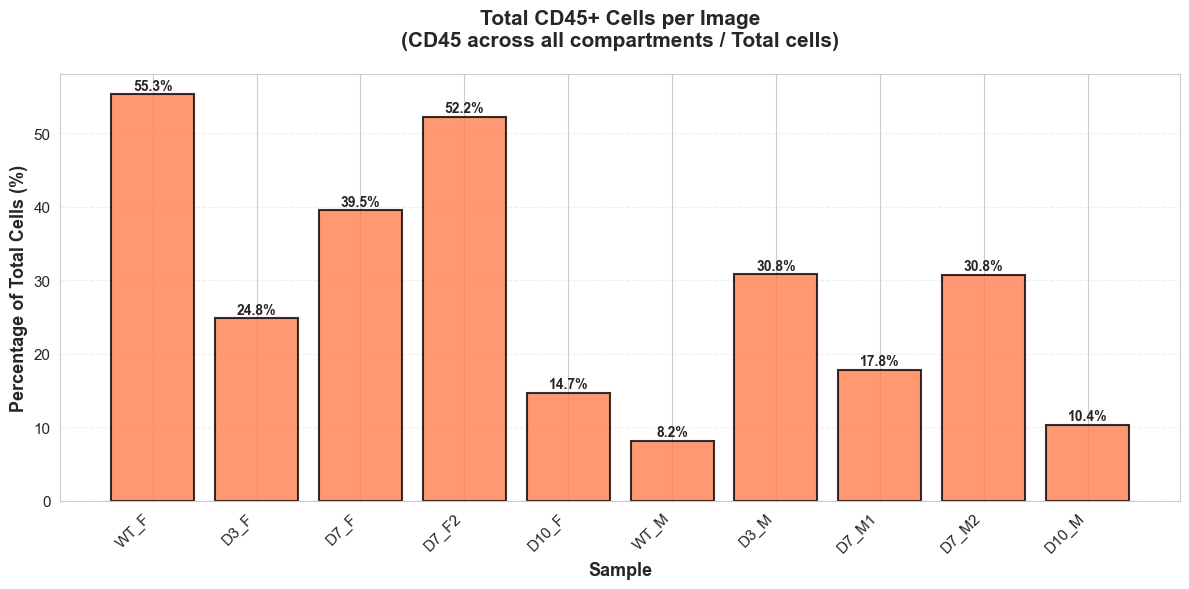


Statistics for Total CD45+ as % of total cells:
  Mean: 28.45%
  Std: 16.58%
  Min: 8.15%
  Max: 55.30%

Detailed breakdown:
  WT_F: 5904 CD45+ / 10677 total = 55.30%
  D3_F: 2060 CD45+ / 8308 total = 24.80%
  D7_F: 5735 CD45+ / 14517 total = 39.51%
  D7_F2: 7031 CD45+ / 13460 total = 52.24%
  D10_F: 1547 CD45+ / 10505 total = 14.73%
  WT_M: 603 CD45+ / 7396 total = 8.15%
  D3_M: 2439 CD45+ / 7922 total = 30.79%
  D7_M1: 1892 CD45+ / 10606 total = 17.84%
  D7_M2: 3412 CD45+ / 11091 total = 30.76%
  D10_M: 910 CD45+ / 8774 total = 10.37%


In [72]:
print("="*80)
print("PLOT 1: Total CD45 as Percentage of Total Cells")
print("="*80)

cd45_totals = plot_total_cd45_percentage(counts_df, fov_total_cells_renamed, cell_class='CD45')


PLOT 2: CD45 Distribution Across Compartments


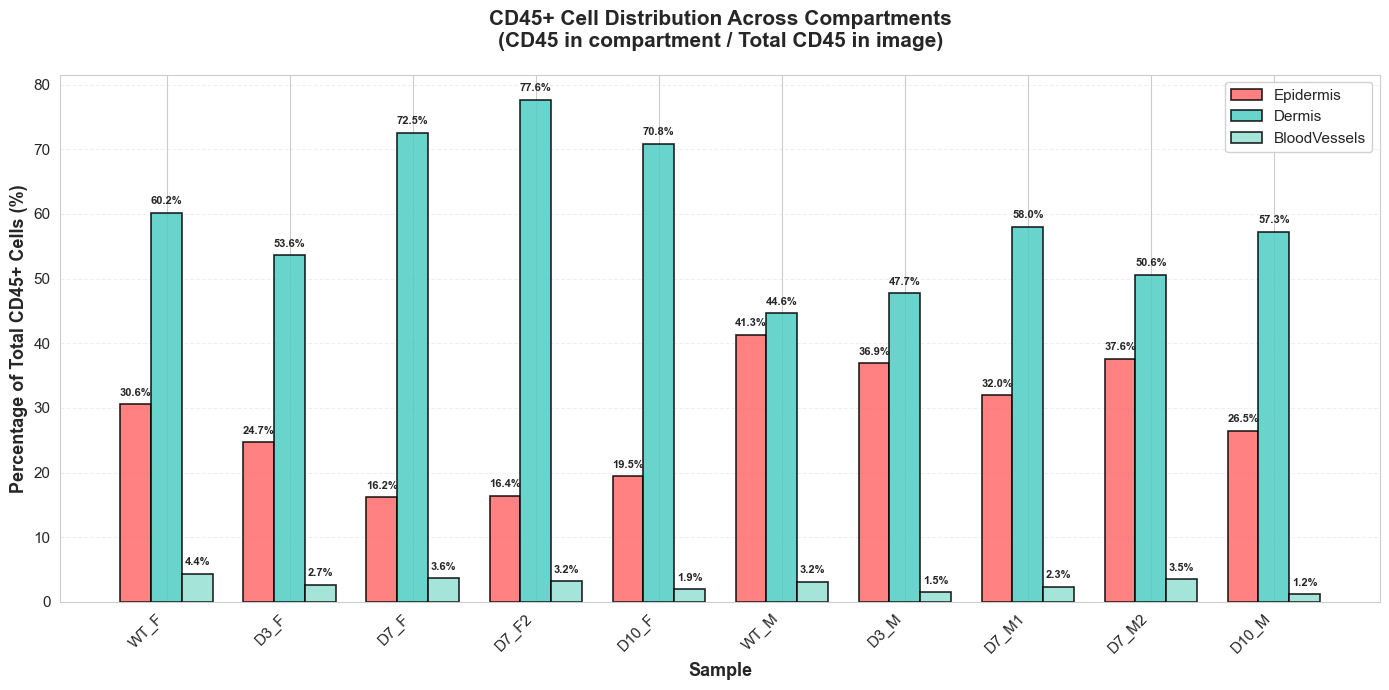


CD45+ Distribution Across Compartments (as % of total CD45):
compartment  Epidermis     Dermis  BloodVessels
fov                                            
WT_F         30.589431  60.179539      4.369919
D3_F         24.708738  53.640777      2.669903
D7_F         16.181343  72.519616      3.626853
D7_F2        16.427251  77.627649      3.200114
D10_F        19.457014  70.846800      1.939237
WT_M         41.293532  44.610282      3.150912
D3_M         36.900369  47.724477      1.476015
D7_M1        31.976744  57.980973      2.325581
D7_M2        37.602579  50.556858      3.487691
D10_M        26.483516  57.252747      1.208791

Mean distribution across all samples:
  Epidermis: 28.16% ± 9.01%
  Dermis: 59.29% ± 11.10%
  BloodVessels: 2.75% ± 1.01%


In [75]:
print("\n" + "="*80)
print("PLOT 2: CD45 Distribution Across Compartments")
print("="*80)

cd45_compartment_dist = plot_cd45_compartment_distribution(
    counts_df, 
    cell_class='CD45',
    compartments=['Epidermis', 'Dermis', 'BloodVessels']
)


PLOT 2: CD45 Distribution Across Compartments (with ANOVA)
STATISTICAL ANALYSIS - ANOVA by Compartment

Epidermis
One-way ANOVA:
  F-statistic: 0.8417
  p-value: 0.5189
  Result: NO significant difference between groups (p >= 0.05)

Tukey's HSD Post-hoc Test:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   D10     D3   7.8343 0.8312 -24.2016 39.8701  False
   D10     D7   2.5767 0.9874 -25.1671 30.3206  False
   D10     WT  12.9712 0.5416 -19.0646 45.0071  False
    D3     D7  -5.2576 0.9097 -33.0014 22.4863  False
    D3     WT   5.1369 0.9418 -26.8989 37.1728  False
    D7     WT  10.3945 0.5966 -17.3494 38.1384  False
-----------------------------------------------------

Significant pairwise comparisons (p < 0.05):
  None

Dermis
One-way ANOVA:
  F-statistic: 1.1480
  p-value: 0.4032
  Result: NO significant difference between groups (p >= 0.05)

Tukey's HSD Post-ho

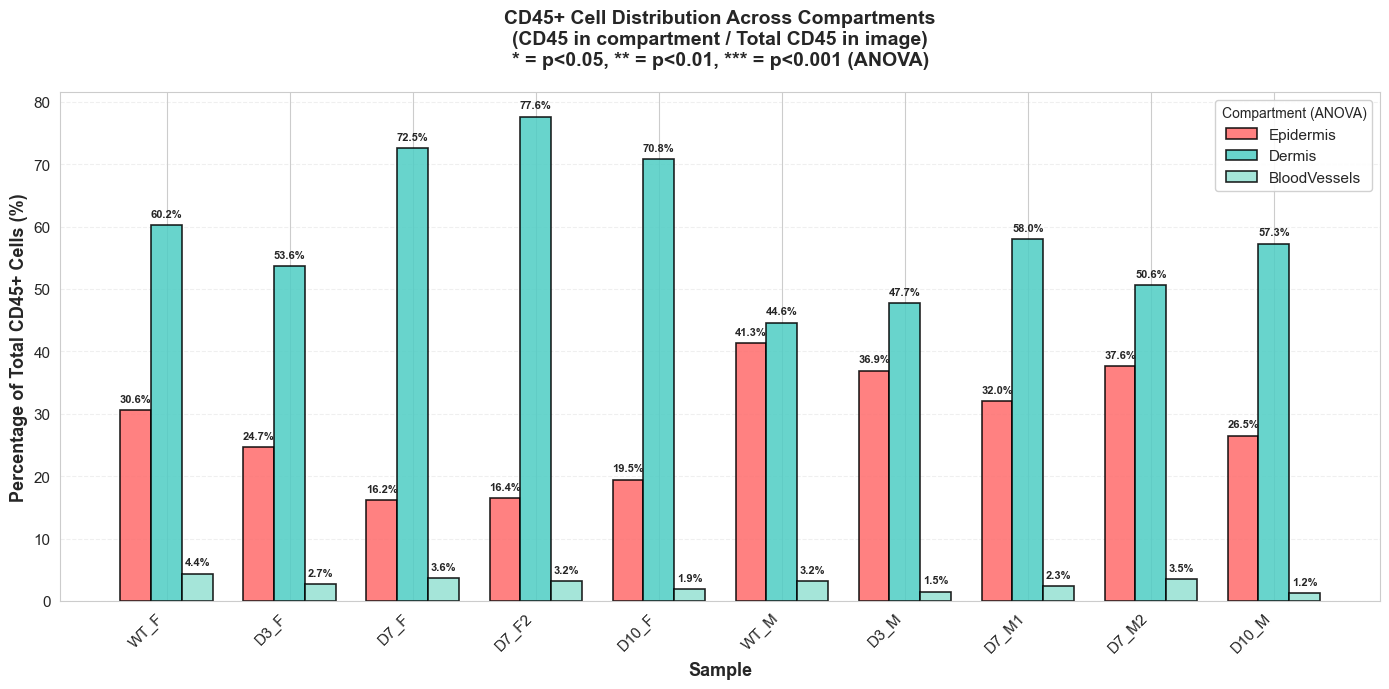


CD45+ Distribution Across Compartments (as % of total CD45):
compartment  Epidermis     Dermis  BloodVessels
fov                                            
WT_F         30.589431  60.179539      4.369919
D3_F         24.708738  53.640777      2.669903
D7_F         16.181343  72.519616      3.626853
D7_F2        16.427251  77.627649      3.200114
D10_F        19.457014  70.846800      1.939237
WT_M         41.293532  44.610282      3.150912
D3_M         36.900369  47.724477      1.476015
D7_M1        31.976744  57.980973      2.325581
D7_M2        37.602579  50.556858      3.487691
D10_M        26.483516  57.252747      1.208791

Mean distribution across all samples:
  Epidermis: 28.16% ± 9.01% (ANOVA p = 0.5189)
  Dermis: 59.29% ± 11.10% (ANOVA p = 0.4032)
  BloodVessels: 2.75% ± 1.01% (ANOVA p = 0.0521)


In [80]:
# Updated function with ANOVA analysis
def plot_cd45_compartment_distribution_with_stats(counts_df, cell_class='CD45', 
                                                   compartments=['Epidermis', 'Dermis', 'BloodVessels']):
    """
    Grouped bar plot showing CD45 distribution across compartments WITH ANOVA statistics.
    Each image has 3 bars (one per compartment) showing CD45_compartment / Total_CD45.
    
    Args:
        counts_df: DataFrame with columns [fov, compartment, class, count]
        cell_class: Cell class to plot (default 'CD45')
        compartments: List of compartments to include in plot
    
    Returns:
        Dictionary with pivot table and statistical results
    """
    from scipy.stats import f_oneway
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    
    # Filter for CD45 only
    cd45_data = counts_df[counts_df['class'] == cell_class].copy()
    
    # Calculate total CD45 per FOV (across all compartments)
    total_cd45_per_fov = cd45_data.groupby('fov')['count'].sum().to_dict()
    
    # Add total CD45 column
    cd45_data['total_cd45_in_fov'] = cd45_data['fov'].map(total_cd45_per_fov)
    
    # Calculate percentage of total CD45
    cd45_data['percentage_of_cd45'] = (cd45_data['count'] / cd45_data['total_cd45_in_fov']) * 100
    
    # Filter to only the compartments we want to plot
    cd45_data = cd45_data[cd45_data['compartment'].isin(compartments)]
    
    # Add grouping variable for statistics
    def get_group(fov_name):
        if 'WT' in fov_name:
            return 'WT'
        elif 'D3' in fov_name:
            return 'D3'
        elif 'D7' in fov_name:
            return 'D7'
        elif 'D10' in fov_name:
            return 'D10'
        else:
            return 'Other'
    
    cd45_data['group'] = cd45_data['fov'].apply(get_group)
    
    # ========================================================================
    # STATISTICAL ANALYSIS - Perform ANOVA for each compartment
    # ========================================================================
    print("="*80)
    print("STATISTICAL ANALYSIS - ANOVA by Compartment")
    print("="*80)
    
    stats_results = {}
    
    for compartment in compartments:
        print(f"\n{'='*80}")
        print(f"{compartment}")
        print('='*80)
        
        comp_data = cd45_data[cd45_data['compartment'] == compartment]
        
        # Prepare data for ANOVA
        groups = comp_data['group'].unique()
        group_data = [comp_data[comp_data['group'] == group]['percentage_of_cd45'].values 
                      for group in groups]
        
        # Perform one-way ANOVA
        f_stat, p_value = f_oneway(*group_data)
        
        print(f"One-way ANOVA:")
        print(f"  F-statistic: {f_stat:.4f}")
        print(f"  p-value: {p_value:.4f}")
        
        if p_value < 0.05:
            print(f"  Result: SIGNIFICANT difference between groups (p < 0.05)")
        else:
            print(f"  Result: NO significant difference between groups (p >= 0.05)")
        
        # Perform Tukey's HSD post-hoc test
        print(f"\nTukey's HSD Post-hoc Test:")
        tukey_result = pairwise_tukeyhsd(comp_data['percentage_of_cd45'], comp_data['group'], alpha=0.05)
        print(tukey_result)
        
        # Extract significant pairs
        tukey_df = pd.DataFrame(data=tukey_result.summary().data[1:], 
                               columns=tukey_result.summary().data[0])
        tukey_df['reject'] = tukey_df['reject'].astype(bool)
        significant_pairs = tukey_df[tukey_df['reject'] == True]
        
        print(f"\nSignificant pairwise comparisons (p < 0.05):")
        if len(significant_pairs) > 0:
            for idx, row in significant_pairs.iterrows():
                print(f"  {row['group1']} vs {row['group2']}: p = {row['p-adj']:.4f}")
        else:
            print("  None")
        
        # Store results
        stats_results[compartment] = {
            'anova_f': f_stat,
            'anova_p': p_value,
            'tukey_result': tukey_result,
            'tukey_df': tukey_df,
            'significant_pairs': significant_pairs
        }
    
    # ========================================================================
    # CREATE VISUALIZATION
    # ========================================================================
    
    # Define custom order for FOVs
    fov_order = ['WT_F', 'D3_F', 'D7_F', 'D7_F2', 'D10_F', 'WT_M', 'D3_M', 'D7_M1', 'D7_M2', 'D10_M']
    fov_order = [fov for fov in fov_order if fov in cd45_data['fov'].values]
    
    # Pivot data for grouped bar plot
    pivot_data = cd45_data.pivot_table(
        index='fov', 
        columns='compartment', 
        values='percentage_of_cd45', 
        fill_value=0
    )
    
    # Reindex to match fov_order
    pivot_data = pivot_data.reindex(fov_order)
    
    # Ensure compartments are in the desired order
    pivot_data = pivot_data[compartments]
    
    # Create grouped bar plot
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Set width and positions
    x = np.arange(len(pivot_data.index))
    width = 0.25
    
    # Define colors for each compartment
    colors = {
        'Epidermis': '#FF6B6B',      # Red
        'Dermis': '#4ECDC4',          # Teal
        'BloodVessels': '#95E1D3'    # Light green
    }
    
    # Create bars for each compartment
    for i, compartment in enumerate(compartments):
        offset = width * (i - 1)  # Center the groups
        
        # Add asterisks to label if significant ANOVA
        label_text = compartment
        if stats_results[compartment]['anova_p'] < 0.001:
            label_text += " ***"
        elif stats_results[compartment]['anova_p'] < 0.01:
            label_text += " **"
        elif stats_results[compartment]['anova_p'] < 0.05:
            label_text += " *"
        
        bars = ax.bar(x + offset, pivot_data[compartment], width, 
                     label=label_text, color=colors[compartment], 
                     edgecolor='black', alpha=0.85, linewidth=1.2)
        
        # Add value labels on bars
        for j, (idx, value) in enumerate(pivot_data[compartment].items()):
            if value > 0:  # Only show label if there's a value
                ax.text(j + offset, value + 1, f'{value:.1f}%', 
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Customize plot
    ax.set_xlabel('Sample', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'Percentage of Total {cell_class}+ Cells (%)', fontsize=13, fontweight='bold')
    ax.set_title(f'{cell_class}+ Cell Distribution Across Compartments\n({cell_class} in compartment / Total {cell_class} in image)\n* = p<0.05, ** = p<0.01, *** = p<0.001 (ANOVA)', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_data.index, rotation=45, ha='right', fontsize=11)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9, title='Compartment (ANOVA)')
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print(f"{cell_class}+ Distribution Across Compartments (as % of total {cell_class}):")
    print("="*80)
    print(pivot_data.to_string())
    
    print(f"\nMean distribution across all samples:")
    for compartment in compartments:
        mean_pct = pivot_data[compartment].mean()
        std_pct = pivot_data[compartment].std()
        p_val = stats_results[compartment]['anova_p']
        p_text = f"p = {p_val:.4f}" if p_val >= 0.001 else "p < 0.001"
        print(f"  {compartment}: {mean_pct:.2f}% ± {std_pct:.2f}% (ANOVA {p_text})")
    
    return {
        'pivot_data': pivot_data,
        'stats_results': stats_results,
        'cd45_data': cd45_data
    }


# Execute the function with statistics
print("\n" + "="*80)
print("PLOT 2: CD45 Distribution Across Compartments (with ANOVA)")
print("="*80)

results = plot_cd45_compartment_distribution_with_stats(
    counts_df, 
    cell_class='CD45',
    compartments=['Epidermis', 'Dermis', 'BloodVessels']
)

# Access the results
cd45_compartment_dist = results['pivot_data']
compartment_stats = results['stats_results']

## 11. Summary Statistics

In [48]:
# Overall summary
print("="*80)
print("OVERALL SUMMARY")
print("="*80)

print(f"\nTotal FOVs processed: {len(all_fov_data)}")
print(f"Compartments analyzed: {list(COMPARTMENT_MAPPING.values())}")
print(f"Cell classes found: {sorted(counts_df['class'].unique())}")

print("\nTotal cells per compartment (all FOVs):")
for compartment in sorted(counts_df['compartment'].unique()):
    total = counts_df[counts_df['compartment'] == compartment]['count'].sum()
    print(f"  {compartment}: {total}")

print("\nTotal cells per class (all compartments):")
for cell_class in sorted(counts_df['class'].unique()):
    total = counts_df[counts_df['class'] == cell_class]['count'].sum()
    print(f"  {cell_class}: {total}")

OVERALL SUMMARY

Total FOVs processed: 10
Compartments analyzed: ['Epidermis', 'Dermis', 'Cartilage', 'Follicles', 'Blood_vessels']
Cell classes found: ['CD45', 'CD45-', 'vessels_CD45', 'vessels_CD45-']

Total cells per compartment (all FOVs):
  Blood: 2506
  Cartilage: 16529
  Dermis: 43388
  Epidermis: 31154
  Follicles: 8377

Total cells per class (all compartments):
  CD45: 30528
  CD45-: 68920
  vessels_CD45: 1005
  vessels_CD45-: 1501


## 12. Export Data for Further Analysis

In [ ]:
# Export the averaged data
avg_counts.to_csv('average_counts_by_compartment_class.csv', index=False)
print("Average counts saved to 'average_counts_by_compartment_class.csv'")

# Export per-FOV summary
fov_summary = counts_df.groupby(['fov', 'compartment'])['count'].sum().reset_index()
fov_summary.columns = ['fov', 'compartment', 'total_cells']
fov_summary.to_csv('fov_compartment_totals.csv', index=False)
print("Per-FOV compartment totals saved to 'fov_compartment_totals.csv'")